In [52]:
# generate dataset in the current directory
# Generate a dataset of StudyHours and Marks (1000 samples) and save it as a CSV file in current directory
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Set random seed for reproducibility
np.random.seed(42)

# Generate random study hours between 0 and 10 
study_hours = np.random.uniform(0, 10, size=1000)
# Generate marks based on study hours with some random noise
# add some noise to make it more realistic  
marks = 2.5 * study_hours + np.random.normal(0, 5, size=1000)  
# Create a DataFrame and save to CSV
df = pd.DataFrame({'StudyHours': study_hours, 'Marks': marks})
df.to_csv('study_hours_marks.csv', index=False)
df.head()


,StudyHours,Marks
0,3.745401,10.252008
1,9.507143,17.091136
2,7.319939,20.200838
3,5.986585,18.019391
4,1.560186,6.699418


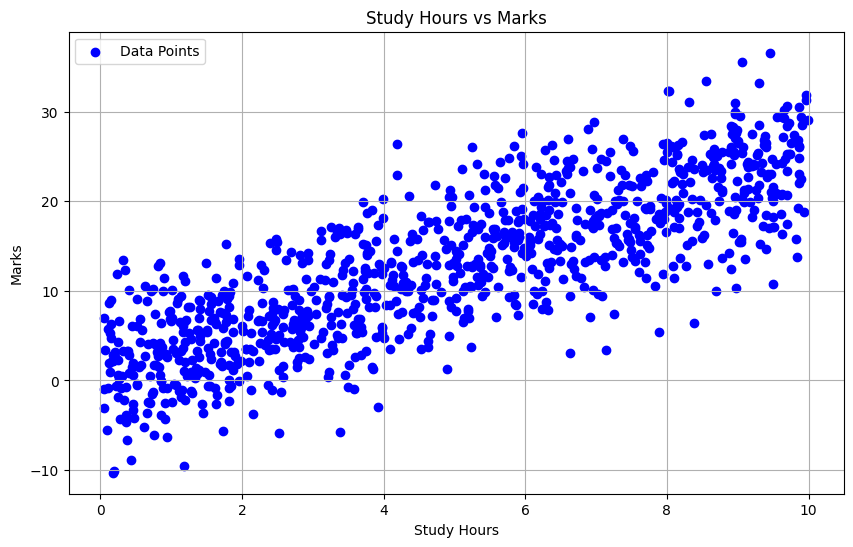

In [53]:
# Plotting the dataset
plt.figure(figsize=(10, 6))
plt.scatter(df['StudyHours'], df['Marks'], color='blue', label='Data Points')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks')
plt.grid(True)
plt.legend()
plt.show()

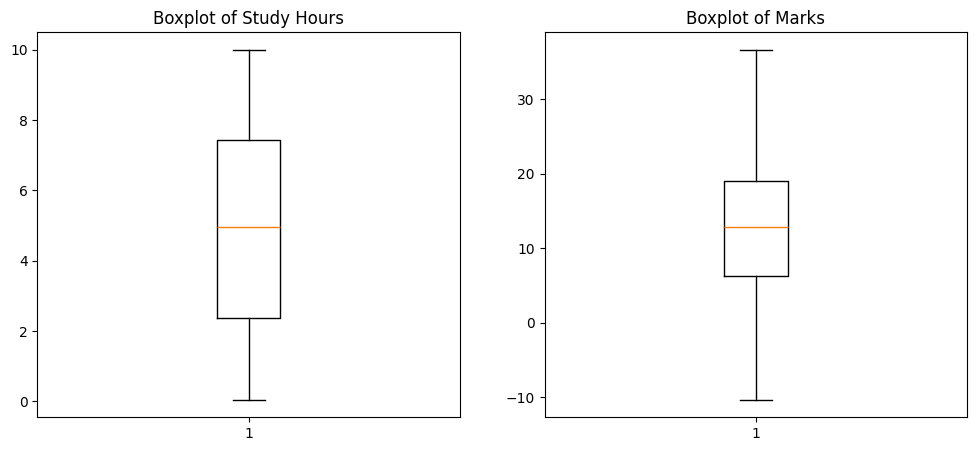

In [54]:
# check for outliers and scale the data if necessary
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df['StudyHours'])
plt.title('Boxplot of Study Hours')
plt.subplot(1, 2, 2)
plt.boxplot(df['Marks'])
plt.title('Boxplot of Marks')
plt.show()


In [55]:
# Remove outliers and scale the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head()

,StudyHours,Marks
0,-0.396301,-0.289682
1,1.576957,0.503141
2,0.827893,0.863633
3,0.371251,0.610749
4,-1.144685,-0.701515


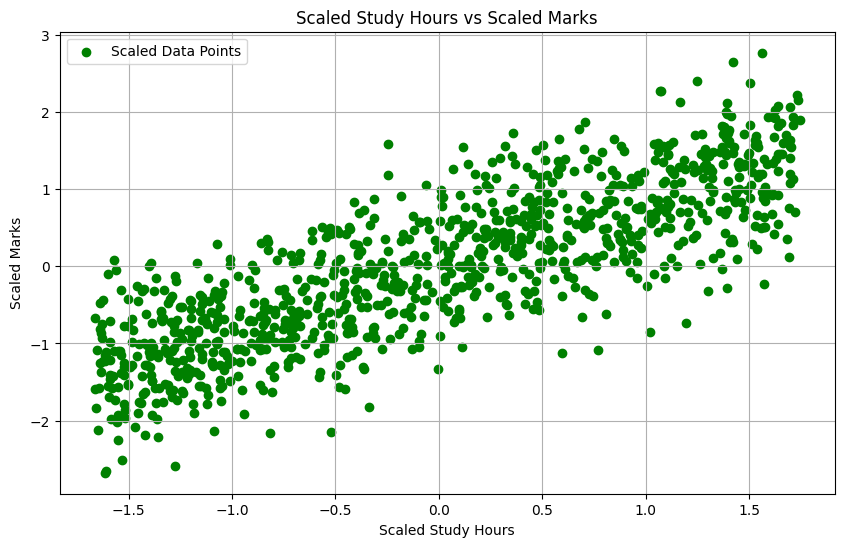

In [56]:
# Plot the scaled dataset
plt.figure(figsize=(10, 6))
plt.scatter(df_scaled['StudyHours'], df_scaled['Marks'], color='green', label='Scaled Data Points')
plt.xlabel('Scaled Study Hours')
plt.ylabel('Scaled Marks')
plt.title('Scaled Study Hours vs Scaled Marks')
plt.grid(True)
plt.legend()
plt.show()

In [57]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

In [58]:
# Fit a linear regression model (closed form solver)
lin_reg = LinearRegression()
lin_reg.fit(df[['StudyHours']], df['Marks'])

print("m: ", lin_reg.coef_[0])
print("c: ", lin_reg.intercept_)

m:  2.422607418472327
c:  0.8739012924655079


In [59]:
# Compute the Cost (MSE) using a library
y_pred = lin_reg.predict(df[['StudyHours']])
mse = mean_squared_error(df['Marks'], y_pred)
print("Cost (MSE): ", mse)

Cost (MSE):  24.374197044486447


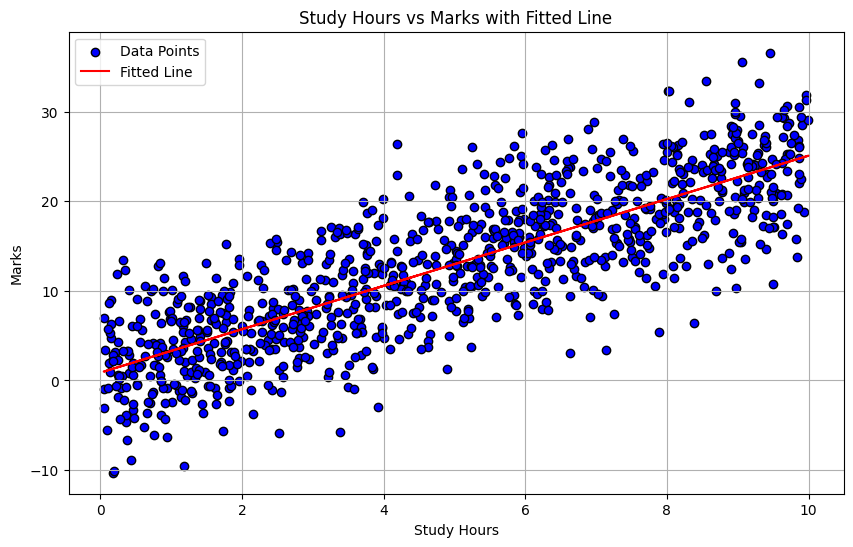

In [60]:
# visualize the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(df['StudyHours'], df['Marks'], color = 'blue', edgecolors = 'black', label='Data Points') 
plt.plot(df['StudyHours'], y_pred, color = 'red', label='Fitted Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks with Fitted Line')
plt.grid(True)
plt.legend()
plt.show()

In [64]:
# SGD Regressor
sgd_reg = SGDRegressor(
    max_iter=1000,
    learning_rate='invscaling',
    eta0=0.01,
    random_state=42
)

sgd_reg.fit(df[['StudyHours']], df['Marks'])

print("m (SGD): ", sgd_reg.coef_[0])
print("c (SGD): ", sgd_reg.intercept_[0])

pred_sgd = sgd_reg.predict(df[['StudyHours']])
mse_sgd = mean_squared_error(df['Marks'], pred_sgd)
print("Cost (MSE) for SGD: ", mse_sgd)

print("m: ", lin_reg.coef_[0])
print("c: ", lin_reg.intercept_)
print("Cost (MSE): ", mse)


m (SGD):  2.5023185253412112
c (SGD):  0.8938140224465798
Cost (MSE) for SGD:  24.59704520640026
m:  2.422607418472327
c:  0.8739012924655079
Cost (MSE):  24.374197044486447


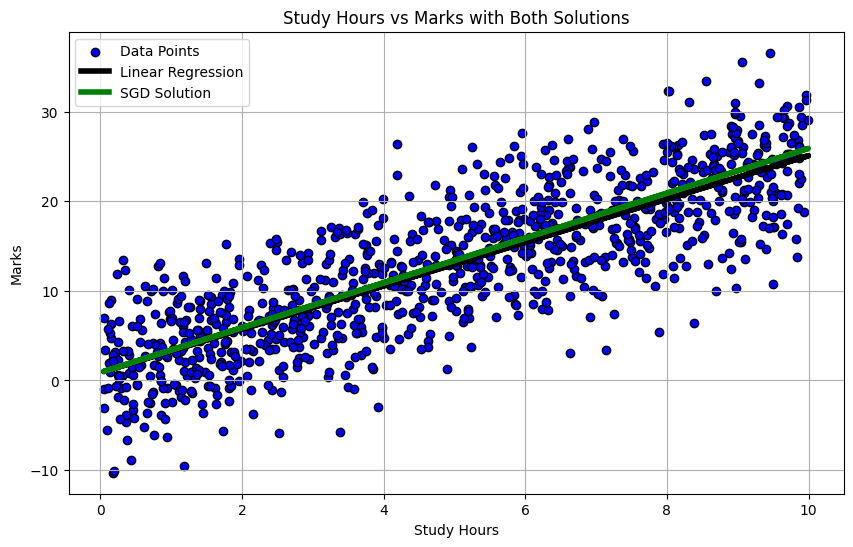

In [73]:
# Compare both lines visually
plt.figure(figsize=(10, 6))
plt.scatter(df['StudyHours'], df['Marks'], color='blue', label='Data Points', edgecolors='black')
plt.plot(df['StudyHours'], y_pred, color='black', label='Linear Regression', linewidth=4)
plt.plot(df['StudyHours'], pred_sgd, color='green', label='SGD Solution', linewidth=4)
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks with Both Solutions')
plt.grid(True)
plt.legend()
plt.show()  

# Evaluation Matrixes

## MAE (Mean Absolute Error)
Formula:
$$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$
Where:
- $n$ is the number of data points
- $y_i$ is the actual value
- $\hat{y}_i$ is the predicted value:


## MSE (Mean Squared Error)
Formula:
$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
Where:
- $n$ is the number of data points
- $y_i$ is the actual value
- $\hat{y}_i$ is the predicted value

# RMSE (Root Mean Squared Error)
Formula:
$$ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$
Where:
- $n$ is the number of data points
- $y_i$ is the actual value
- $\hat{y}_i$ is the predicted value

# What MAE, MSE and RMSE does? 

MAE: It measures the average magnitude of the errors in a set of predictions, without considering their direction. It gives an idea of how far off the predictions are from the actual values on average.

MSE: It measures the average of the squares of the errors, giving more weight to larger errors. It is useful when you want to penalize larger errors more than smaller ones.

RMSE: It is the square root of the MSE, providing an error metric in the same units as the original data. It is often used to compare the performance of different models or to evaluate the accuracy of predictions.

# What is R-squared (R²) and Adjusted R-squared? 

## R-squared (R²)
R-squared, also known as the coefficient of determination, is a statistical measure that represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). It ranges from 0 to 1, where:
- 0 indicates that the model does not explain any of the variance in the dependent variable.
- 1 indicates that the model explains all the variance in the dependent variable.
- Values between 0 and 1 indicate the proportion of variance explained by the model.
- A higher R-squared value indicates a better fit of the model to the data.
- However, R-squared can be misleading when comparing models with different numbers of independent variables, as it tends to increase with the addition of more variables, even if they do not contribute to the model's predictive power.

## Adjusted R-squared
Adjusted R-squared is a modified version of R-squared that takes into account the number of independent variables in the model. It adjusts the R-squared value based on the number of predictors, providing a more accurate measure of model fit when comparing models with different numbers of independent variables. The formula for Adjusted R-squared is:
$$ \text{Adjusted } R^2 = 1 - \left( \frac{(1 - R^2)(n - 1)}{n - k - 1} \right) $$
Where:
- $R^2$ is the R-squared value of the model
- $n$ is the number of observations
- $k$ is the number of independent variables in the model
- Adjusted R-squared can be negative if the model is a poor fit to the data, and it can be used to compare models with different numbers of independent variables, as it penalizes the addition of irrelevant predictors. A higher Adjusted R-squared value indicates a better fit of the model to the data, while accounting for the number of predictors used.   
- In summary, R-squared measures the proportion of variance explained by the model, while Adjusted R-squared provides a more accurate measure of model fit by adjusting for the number of predictors.

In [75]:
# RMSE (Root Mean Squared Error) Calculation 

rmse = np.sqrt(mse)
print("Cost (RMSE): ", rmse)

# R-squared (Coefficient of Determination) Calculation
from sklearn.metrics import r2_score
r2 = r2_score(df['Marks'], y_pred)
print("R-squared: ", r2)    

Cost (RMSE):  4.937023095397311
R-squared:  0.6724464844425475
